# Requirements

This notebook uses the following third-party packages:

- opencv-python
- numpy
- matplotlib

Standard library modules used here:

- csv
- os

In [42]:
%pip install --upgrade pip
%pip install opencv-python numpy matplotlib pandas

Looking in indexes: https://pypi.org/simple, https://www.piwheels.org/simple
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.org/simple, https://www.piwheels.org/simple
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 9.2 MB/s  0:00:016m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pandas]2m2/3 [pandas]
Note: you may need to restart the kernel to use updated packages.


In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import csv
import os
import pandas as pd

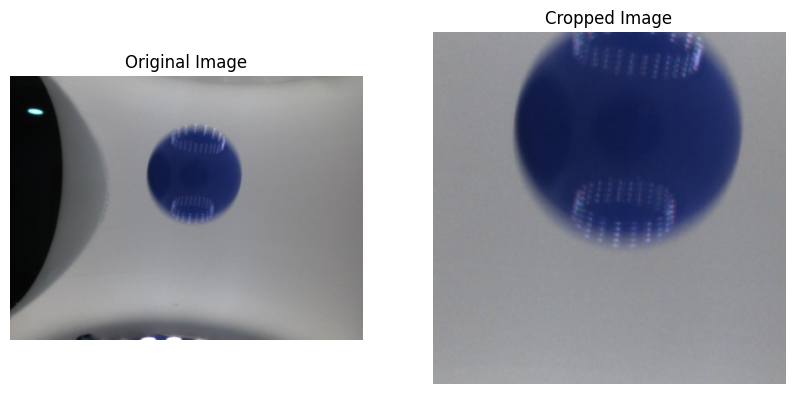

In [44]:

image_path = "out/frame_0001.png"
csv_filename = "marble_dataset.csv"
visualize = True

# --- 1. Load Image ---
# In production, you will likely pass the frame directly from cap.read() 
# instead of reading from the disk to save heavy I/O time.
frame_bgr = cv2.imread(image_path)

if frame_bgr is None:
    print(f"Error: Could not load image at {image_path}")
    exit()

height, width = frame_bgr.shape[:2]

# --- 2. Fast Cropping ---
crop_w, crop_h = 300, 300
start_x = width // 2 - crop_w // 2
start_y = height // 2 - crop_h // 2

# Slicing the numpy array is an extremely fast O(1) operation
center_crop = frame_bgr[start_y:start_y+crop_h, start_x:start_x+crop_w]

# show old image and new image side by side
if visualize:
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Cropped Image")
    plt.imshow(cv2.cvtColor(center_crop, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.show()




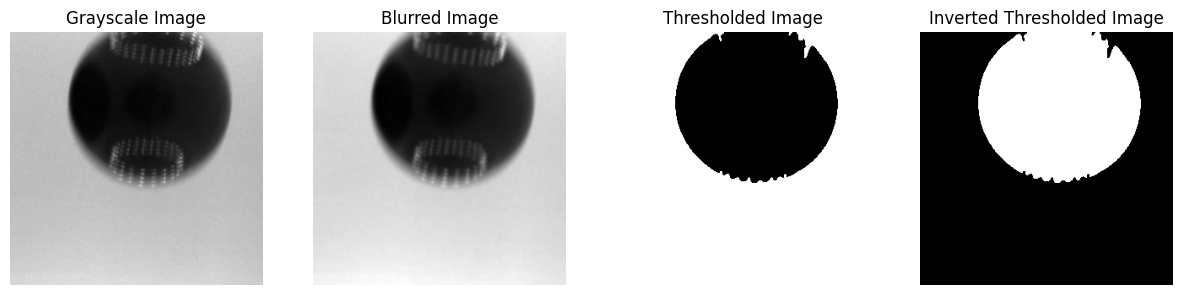

In [45]:
# --- 3. Optimized Processing ---
# Convert ONLY the small 300x300 crop to Grayscale (faster than converting the whole image)
frame_gray = cv2.cvtColor(center_crop, cv2.COLOR_BGR2GRAY)

# Reduced blur kernel from (9,9) to (5,5) for speed. Adjust if noise is too high.
blurred = cv2.GaussianBlur(frame_gray, (5, 5), 0)

# Thresholding
_, thresh = cv2.threshold(blurred, 100, 255, cv2.THRESH_BINARY)

# Invert Threshold
inv_thresh = cv2.bitwise_not(thresh)

# visualize the frame_gray, blurred and thresholded image
if visualize:
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 4, 1)
    plt.title("Grayscale Image")
    plt.imshow(frame_gray, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.title("Blurred Image")
    plt.imshow(blurred, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.title("Thresholded Image")
    plt.imshow(thresh, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 4, 4)
    plt.title("Inverted Thresholded Image")
    plt.imshow(inv_thresh, cmap='gray')
    plt.axis('off')

    plt.show()

Total contours found: 1


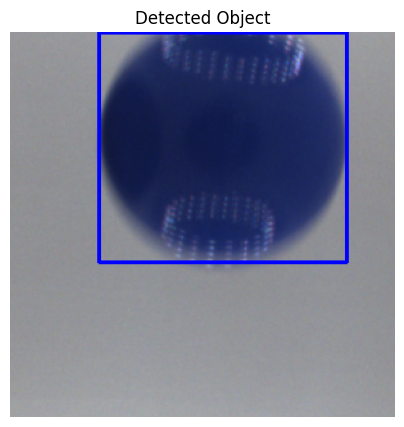

In [46]:
# --- 4. Contour Detection ---
contours, _ = cv2.findContours(inv_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print(f"Total contours found: {len(contours)}")

# Initialize coordinates in case nothing is found
x, y, w, h = 0, 0, 0, 0
found_object = False
contour_area = 0

if contours:
    # Filter contours based on area roughly matching previous BlobDetector params
    valid_contours = [c for c in contours if 2000 <= cv2.contourArea(c) <= 100000]
    
    if valid_contours:
        # Grab the largest contour by area
        largest_contour = max(valid_contours, key=cv2.contourArea)
        contour_area = cv2.contourArea(largest_contour)
        x, y, w, h = cv2.boundingRect(largest_contour)
        found_object = True

# visualize the detected object on the cropped image
if visualize:
    output_image = center_crop.copy()
    if found_object:
        cv2.rectangle(output_image, (x, y), (x + w, y + h), (255, 0, 0), 2)

    plt.figure(figsize=(5, 5))
    plt.title("Detected Object")
    plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


Detected color: blue


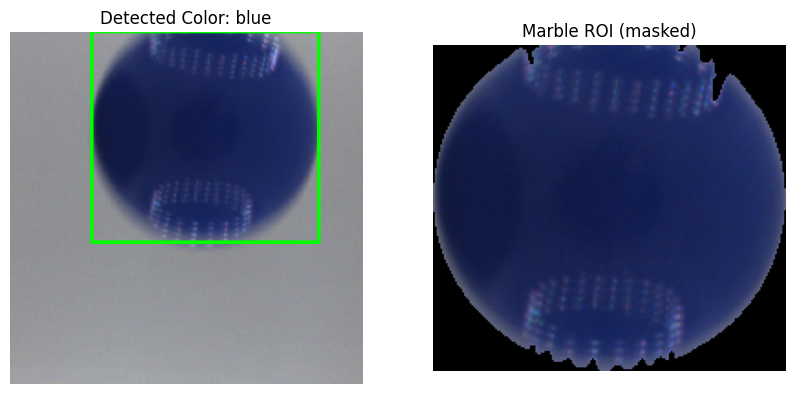

In [47]:
# --- 5. Color Detection ---
# Classify the detected marble into one of: blue, green, black, white, red
# using HSV statistics over the bounding-box ROI (masked to the contour
# so background does not pollute the result).

def classify_color(bgr_roi, mask=None):
    """Return one of: 'red', 'green', 'blue', 'black', 'white'.

    bgr_roi : HxWx3 BGR image (ROI around the marble).
    mask    : optional HxW uint8 mask (0/255) selecting marble pixels.
    """
    if bgr_roi.size == 0:
        return "unknown"

    hsv = cv2.cvtColor(bgr_roi, cv2.COLOR_BGR2HSV)

    if mask is None:
        mask = np.full(bgr_roi.shape[:2], 255, dtype=np.uint8)

    if cv2.countNonZero(mask) == 0:
        return "unknown"

    h = hsv[:, :, 0]
    s = hsv[:, :, 1]
    v = hsv[:, :, 2]

    # Use median to be robust against highlights / shadows.
    m = mask > 0
    h_med = float(np.median(h[m]))
    s_med = float(np.median(s[m]))
    v_med = float(np.median(v[m]))

    # 1) Achromatic checks first (low saturation -> black / white).
    if s_med < 60 and v_med < 70:
        return "black"
    if s_med < 50 and v_med > 170:
        return "white"

    # 2) Chromatic: decide by hue.
    #    OpenCV hue range is 0..179.
    if h_med < 10 or h_med >= 160:
        return "red"
    if 35 <= h_med <= 85:
        return "green"
    if 90 <= h_med <= 135:
        return "blue"

    # Fallbacks for ambiguous hues.
    if v_med < 80:
        return "black"
    if s_med < 60:
        return "white"
    return "red" if (h_med < 20 or h_med > 150) else "unknown"


label = "unknown"
if found_object:
    # ROI from the cropped frame
    roi = center_crop[y:y + h, x:x + w]

    # Build a mask for just this marble using the largest contour
    contour_mask_full = np.zeros(inv_thresh.shape, dtype=np.uint8)
    cv2.drawContours(contour_mask_full, [largest_contour], -1, 255, thickness=cv2.FILLED)
    roi_mask = contour_mask_full[y:y + h, x:x + w]

    label = classify_color(roi, roi_mask)

print(f"Detected color: {label}")

if visualize:
    output_image = center_crop.copy()
    if found_object:
        cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(
            output_image,
            label,
            (x, max(0, y - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2,
        )

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title(f"Detected Color: {label}")
    plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    if found_object:
        plt.subplot(1, 2, 2)
        plt.title("Marble ROI (masked)")
        masked_roi = cv2.bitwise_and(roi, roi, mask=roi_mask)
        plt.imshow(cv2.cvtColor(masked_roi, cv2.COLOR_BGR2RGB))
        plt.axis('off')

    plt.show()


In [48]:
# --- 6. Save Data to CSV ---
# Convert center-based (x, y, w, h) in 300x300 crop to absolute xmin, ymin, xmax, ymax in original image
img_width, img_height = 640, 480
xmin = max(0, int(x - w / 2))
ymin = max(0, int(y - h / 2))
xmax = min(img_width, int(x + w / 2))
ymax = min(img_height, int(y + h / 2))

# label comes from the color-detection step above
# (one of: red, green, blue, black, white, unknown)

file_exists = os.path.isfile(csv_filename)
with open(csv_filename, mode='a', newline='') as file:
    writer = csv.writer(file)

    # If file exists, try to detect whether it already has the correct header
    has_correct_header = False
    if file_exists:
        with open(csv_filename, mode='r', newline='') as check_file:
            reader = csv.reader(check_file)
            first_row = next(reader, None)
            has_correct_header = first_row == [
                'filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax'
            ]

    if not file_exists or not has_correct_header:
        # (Re)write file with correct header
        file.close()
        with open(csv_filename, mode='w', newline='') as file_w:
            writer_w = csv.writer(file_w)
            writer_w.writerow(['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax'])
            writer_w.writerow([
                os.path.basename(image_path),
                img_width,
                img_height,
                label,
                xmin,
                ymin,
                xmax,
                ymax,
            ])
    else:
        writer.writerow([
            os.path.basename(image_path),
            img_width,
            img_height,
            label,
            xmin,
            ymin,
            xmax,
            ymax,
        ])

# show csv file as table
df = pd.read_csv(csv_filename)
df


,filename,width,height,class,xmin,ymin,xmax,ymax
0,frame_0001.png,640,480,blue,0,0,165,89
